In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import AgglomerativeClustering

from sklearn.manifold import TSNE
import numpy as np

In [10]:
file = "norm_6.csv"
klasteriu_sk = 11

In [11]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df

In [12]:
if file == "dvi_dim.csv":
   X_tsne = np.array(X)
elif file == "norm_full.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

In [13]:
agg_clustering = AgglomerativeClustering(n_clusters=klasteriu_sk)
y_agg = agg_clustering.fit_predict(X)

df['cluster'] = y_agg

In [14]:
if file != "dvi_dim.csv":
    tsne = TSNE(
        n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
        perplexity=perp,          # kiek artimiausių kaimynų laikoma reikšmingais
        learning_rate=learn_r,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
        max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
        early_exaggeration=early_ex,# padeda atskirti klasterius ir išvengti lokalių minimumų
        metric="euclidean",     # atstumo metrika pradinėje erdvėje
        random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
        init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
    )

    X_tsne = tsne.fit_transform(X)


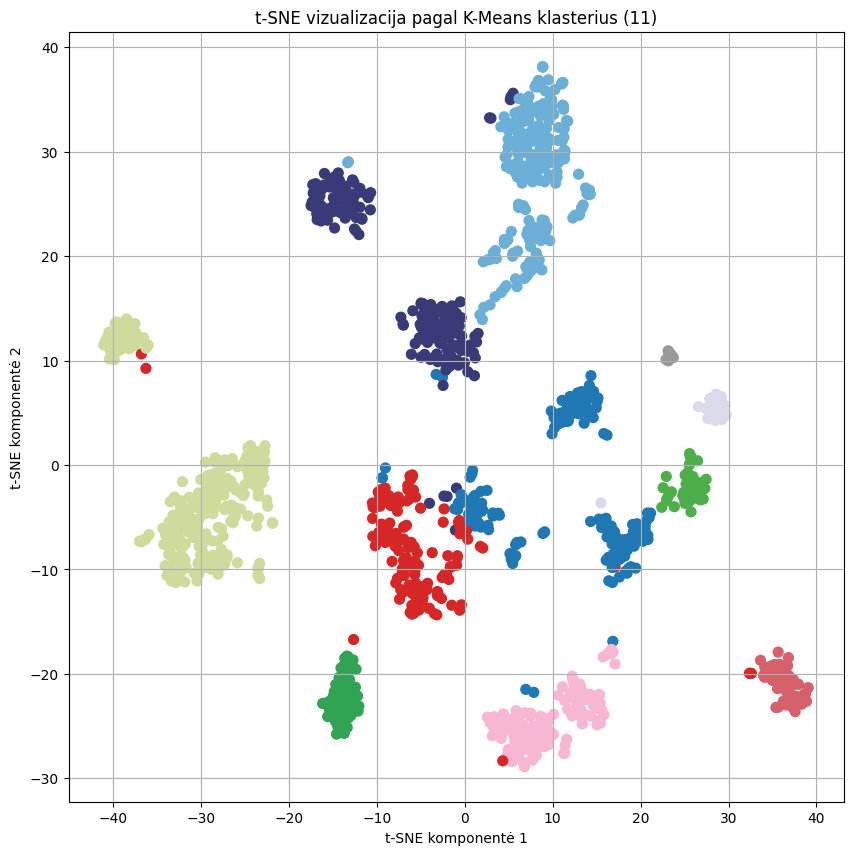

In [15]:
plt.figure(figsize=(10, 10))
colors = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors + plt.cm.Set1.colors
cmap = ListedColormap(colors)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_agg,
    cmap=cmap,
    s=50
)
plt.title(f"t-SNE vizualizacija pagal K-Means klasterius ({klasteriu_sk})")
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.grid(True)
plt.show()
